In [5]:
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms 
device = 'cuda' if torch.cuda.is_available() else 'cpu' #imports

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
]) #normaliza

trn_ds = MNIST('data', transform = img_transform, train = True, download = True)
val_ds = MNIST('data', transform = img_transform, train = False, download = True) #dados treino e teste

batch_size = 128
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False) #ambaralha os dados


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
class ConvAutoEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Conv2d(1, 32, 3, stride=3, padding=1), nn.ReLU(True),
                nn.MaxPool2d(2, stride=2),
                nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
                nn.MaxPool2d(2, stride=1) #convolucao e pooling
            )
            self.decoder = nn.Sequential(
                nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True),
                nn.ConvTranspose2d(32, 16, 5, stride=3, padding=1), nn.ReLU(True),
                nn.ConvTranspose2d(16, 1, 2, stride=2, padding=1), nn.Tanh() #desconvolui
            )
        def forward(self, x):
            x = self.encoder(x)
            x = self.decoder(x)
            return x #fluxo
    
model = ConvAutoEncoder().to(device) #cria o modelo
!pip install torch_summary
from torchsummary import summary
summary(model, torch.zeros(2,1,28,28)); #sumario do modelo

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 2, 2]            --
|    └─Conv2d: 2-1                       [-1, 32, 10, 10]          320
|    └─ReLU: 2-2                         [-1, 32, 10, 10]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 5, 5]            --
|    └─Conv2d: 2-4                       [-1, 64, 3, 3]            18,496
|    └─ReLU: 2-5                         [-1, 64, 3, 3]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 2, 2]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 5, 5]            18,464
|    └─ReLU: 2-8                         [-1, 32, 5, 5]            --
|    └─ConvTra

In [8]:
def train_batch(input, model, criterion, optimizer):
    model.train() #treino
    optimizer.zero_grad() #zera os gradientes
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step() #atualiza
    return loss

In [9]:
@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval() #avalia
    output = model(input)
    loss = criterion(output, input) #erro de teste
    return loss

In [10]:
model = ConvAutoEncoder().to(device)
criterion = nn.MSELoss() #erro
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5) #otimizador

In [11]:
num_epochs = 5
log = Report(num_epochs) #epochs e log

for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl): #pra cada btach dentro de epoch
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r') #treina e pega o erro
    
    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r') #testa todos os batchs e guarda o erro
    log.report_avgs(epoch+1)

EPOCH: 1.000  trn_loss: 0.169  val_loss: 0.097  (7.94s - 31.75s remaining)
EPOCH: 2.000  trn_loss: 0.085  val_loss: 0.074  (16.32s - 24.48s remaining)
EPOCH: 3.000  trn_loss: 0.071  val_loss: 0.064  (26.18s - 17.46s remaining)
EPOCH: 4.000  trn_loss: 0.064  val_loss: 0.060  (35.85s - 8.96s remaining)
EPOCH: 5.000  trn_loss: 0.059  val_loss: 0.055  (44.52s - 0.00s remaining)


100%|██████████████████████████████████████| 106/106 [00:00<00:00, 2517.67it/s]


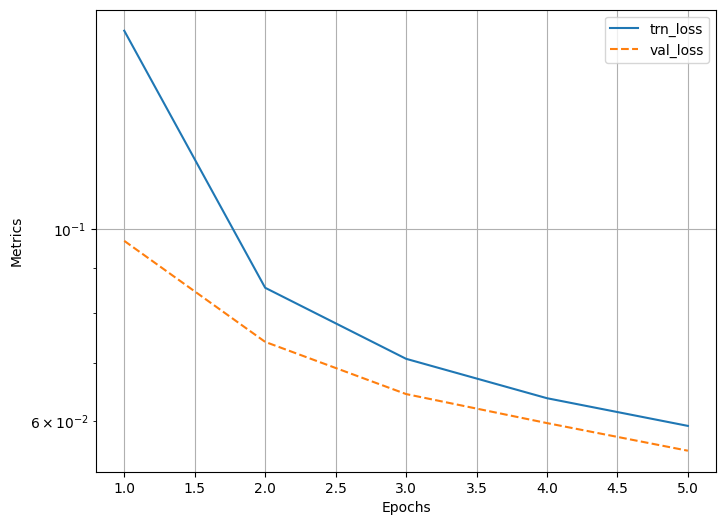

In [12]:
log.plot_epochs(log=True) #mostra o log

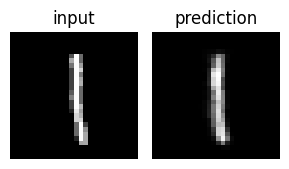

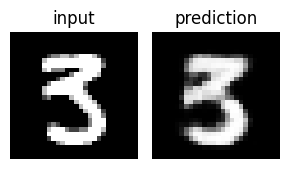

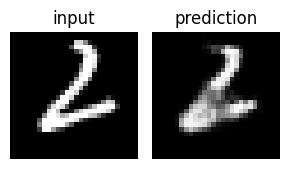

In [14]:
import matplotlib.pyplot as plt
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1, 2, figsize=(3,3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show() #mostra o input e oq foi previsto pelo modelo

In [16]:
latent_vectors = []
classes = [] #listas vazias

In [17]:
for im,clss in val_dl: 
    latent_vectors.append(model.encoder(im).view(len(im),-1))
    classes.extend(clss) #guarda os vetores e coloca nas classes

In [18]:
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy() #coloca os vetores latentes

In [19]:
from sklearn.manifold import TSNE
tsne = TSNE(2) #modelo tsne pra colocar os dados de 2 dimensoes

In [20]:
clustered = tsne.fit_transform(latent_vectors) #coloca o modelo tsne nos vetores latentes

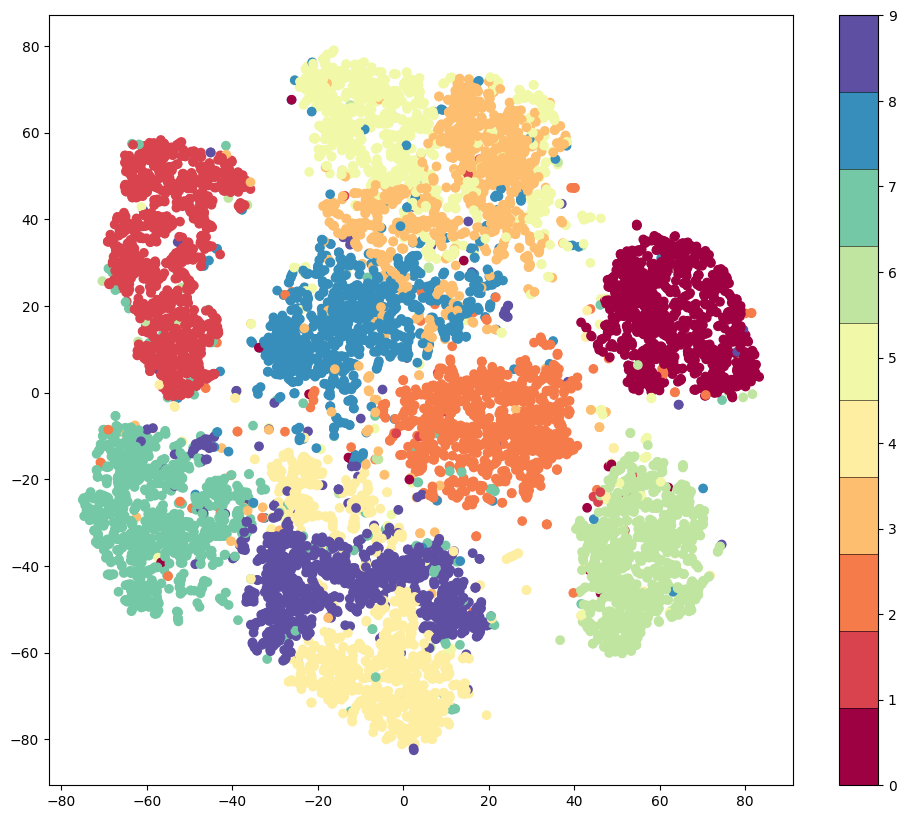

In [21]:
fig = plt.figure(figsize=(12,10))
cmap = plt.get_cmap('Spectral', 10)
plt.scatter(*zip(*clustered), c=classes, cmap=cmap)
plt.colorbar(drawedges=True)  #cada cor uma classe e mostra isso

In [22]:
latent_vectors = []
classes = []
for im,clss in val_dl:
    latent_vectors.append(model.encoder(im))
    classes.extend(clss) 
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy().reshape(10000, -1) #passa as iamgens pro encoder

In [23]:
rand_vectors = []
for col in latent_vectors.transpose(1,0):
    mu, sigma = col.mean(), col.std()
    rand_vectors.append(sigma*torch.randn(1,100) + mu) #pega a media e o dp

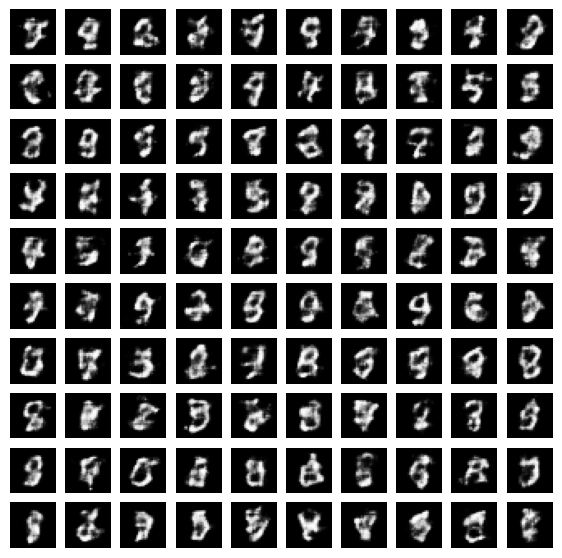

In [24]:
rand_vectors = torch.cat(rand_vectors).transpose(1,0).to(device)
fig, ax = plt.subplots(10,10,figsize=(7,7)); ax = iter(ax.flat)
for p in rand_vectors:
    img = model.decoder(p.reshape(1,64,2,2)).view(28,28)
    show(img, ax=next(ax)) #vai pro decoder pra recriar as iamgens